# Assignment 2.4 — Manual Stable Diffusion inference

This notebook is the complete submission for Assignment 2.4. It loads every Stable Diffusion component individually, performs two U-Net forward passes per DDIM step, compares CFG scales `1, 3, 5, 7.5, 12, 20` with the same initial latent, and provides space for the final sweet-spot analysis. No high-level Diffusers pipeline is used.

In [1]:
# Run once in a clean environment if dependencies are missing:
# %pip install -r ../requirements.txt

import importlib.metadata
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from diffusers import AutoencoderKL, DDIMScheduler, UNet2DConditionModel
from PIL import Image
from tqdm.auto import tqdm
from transformers import CLIPTextModel, CLIPTokenizer

for package in ('torch', 'diffusers', 'transformers'):
    print(f'{package}: {importlib.metadata.version(package)}')

torch: 2.2.2
diffusers: 0.30.3
transformers: 4.46.3


## 1. Controlled configuration

In [2]:
MODEL_ID = 'stable-diffusion-v1-5/stable-diffusion-v1-5'
PROMPT = 'A cinematic photograph of a lighthouse on a rugged coast at sunset, detailed ocean waves'
NULL_PROMPT = ''
GUIDANCE_SCALES = [1, 3, 5, 7.5, 12, 20]
SEED = 2026
HEIGHT = WIDTH = 512
NUM_STEPS = 50
ETA = 0.0

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    DTYPE = torch.float16
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    DTYPE = torch.float32
else:
    DEVICE = torch.device('cpu')
    DTYPE = torch.float32

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'assignment2_4'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print({'device': str(DEVICE), 'dtype': str(DTYPE), 'seed': SEED, 'steps': NUM_STEPS})

{'device': 'mps', 'dtype': 'torch.float32', 'seed': 2026, 'steps': 50}


## 2. Load and connect individual components

In [3]:
tokenizer = CLIPTokenizer.from_pretrained(MODEL_ID, subfolder='tokenizer')
text_encoder = CLIPTextModel.from_pretrained(
    MODEL_ID, subfolder='text_encoder', torch_dtype=DTYPE
).to(DEVICE).eval()
unet = UNet2DConditionModel.from_pretrained(
    MODEL_ID, subfolder='unet', torch_dtype=DTYPE
).to(DEVICE).eval()

scheduler = DDIMScheduler.from_pretrained(MODEL_ID, subfolder='scheduler')
vae = AutoencoderKL.from_pretrained(
    MODEL_ID, subfolder='vae', torch_dtype=DTYPE
).to(DEVICE).eval()

for module in (text_encoder, unet, vae):
    module.requires_grad_(False)
print('Loaded tokenizer, CLIP text encoder, U-Net, DDIM scheduler, and VAE separately.')

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loaded tokenizer, CLIP text encoder, U-Net, DDIM scheduler, and VAE separately.


## 3. Encode prompt and null prompt

In [4]:
@torch.inference_mode()
def encode_text(text):
    tokens = tokenizer(
        text,
        padding='max_length',
        max_length=tokenizer.model_max_length,
        truncation=True,
        return_tensors='pt',
    )
    attention_mask = None
    if getattr(text_encoder.config, 'use_attention_mask', False):
        attention_mask = tokens.attention_mask.to(DEVICE)
    return text_encoder(
        tokens.input_ids.to(DEVICE), attention_mask=attention_mask
    ).last_hidden_state

cond_embeddings = encode_text(PROMPT)
uncond_embeddings = encode_text(NULL_PROMPT)
assert cond_embeddings.shape == uncond_embeddings.shape
print('Conditional embedding:', tuple(cond_embeddings.shape))
print('Unconditional embedding:', tuple(uncond_embeddings.shape))

Conditional embedding: (1, 77, 768)
Unconditional embedding: (1, 77, 768)


## 4. Create one seeded initial latent

In [5]:
vae_scale_factor = 2 ** (len(vae.config.block_out_channels) - 1)
latent_shape = (
    1, unet.config.in_channels, HEIGHT // vae_scale_factor, WIDTH // vae_scale_factor
)
generator_device = 'cuda' if DEVICE.type == 'cuda' else 'cpu'
generator = torch.Generator(device=generator_device).manual_seed(SEED)
initial_latents = torch.randn(latent_shape, generator=generator, dtype=DTYPE)
initial_latents = initial_latents.to(DEVICE) * scheduler.init_noise_sigma
initial_latents_snapshot = initial_latents.clone()
print('Initial latent:', tuple(initial_latents.shape), 'seed:', SEED)

Initial latent: (1, 4, 64, 64) seed: 2026


## 5. Manual DDIM loop and VAE decoding

The conditional and unconditional predictions below are deliberately two separate U-Net calls, as required by the assignment.

In [6]:
@torch.inference_mode()
def denoise_with_cfg(scale):
    scheduler.set_timesteps(NUM_STEPS, device=DEVICE)
    latents = initial_latents.clone()

    for timestep in tqdm(scheduler.timesteps, desc=f'CFG {scale:g}', leave=False):
        latent_input = scheduler.scale_model_input(latents, timestep)

        # Forward pass 1: unconditional noise prediction.
        uncond_noise = unet(
            latent_input, timestep, encoder_hidden_states=uncond_embeddings
        ).sample

        # Forward pass 2: conditional noise prediction.
        cond_noise = unet(
            latent_input, timestep, encoder_hidden_states=cond_embeddings
        ).sample

        noise = uncond_noise + scale * (cond_noise - uncond_noise)
        latents = scheduler.step(
            noise, timestep, latents, eta=ETA
        ).prev_sample

    return latents


@torch.inference_mode()
def decode_latents(latents):
    scaling_factor = getattr(vae.config, 'scaling_factor', 0.18215)
    image = vae.decode(latents / scaling_factor).sample
    image = (image / 2 + 0.5).clamp(0, 1)
    image = image[0].float().cpu().permute(1, 2, 0).numpy()
    return Image.fromarray((image * 255).round().astype(np.uint8)).convert('RGB')

## 6. Generate and visualize all guidance scales

CFG 1:   0%|          | 0/50 [00:00<?, ?it/s]

CFG 3:   0%|          | 0/50 [00:00<?, ?it/s]

CFG 5:   0%|          | 0/50 [00:00<?, ?it/s]

CFG 7.5:   0%|          | 0/50 [00:00<?, ?it/s]

CFG 12:   0%|          | 0/50 [00:00<?, ?it/s]

CFG 20:   0%|          | 0/50 [00:00<?, ?it/s]

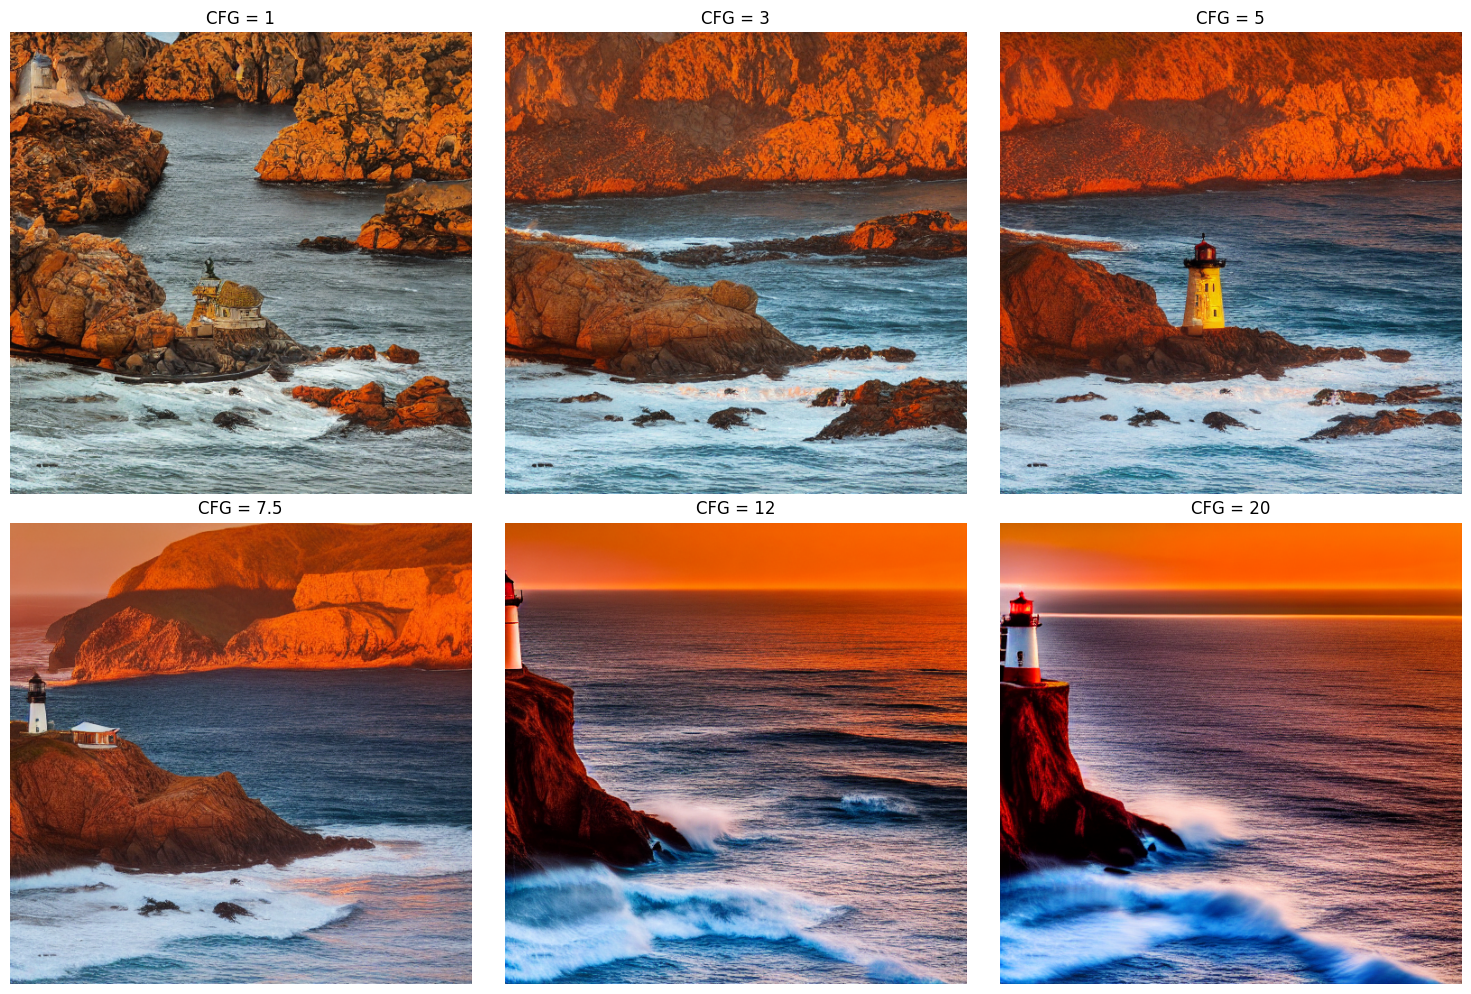

439

In [7]:
images = []
for scale in GUIDANCE_SCALES:
    final_latents = denoise_with_cfg(scale)
    image = decode_latents(final_latents)
    image.save(OUTPUT_DIR / f'cfg_{scale:g}.png')
    images.append(image)

assert torch.equal(initial_latents, initial_latents_snapshot)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for axis, image, scale in zip(axes.flat, images, GUIDANCE_SCALES):
    axis.imshow(image)
    axis.set_title(f'CFG = {scale:g}')
    axis.axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cfg_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

metadata = {
    'model_id': MODEL_ID, 'prompt': PROMPT, 'null_prompt': NULL_PROMPT,
    'scales': GUIDANCE_SCALES, 'seed': SEED, 'height': HEIGHT, 'width': WIDTH,
    'steps': NUM_STEPS, 'eta': ETA, 'device': str(DEVICE), 'dtype': str(DTYPE),
    'initial_latent_shape': list(initial_latents.shape),
}
(OUTPUT_DIR / 'metadata.json').write_text(json.dumps(metadata, indent=2), encoding='utf-8')